In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/graphql-feature-schema-dataset/val.jsonl
/kaggle/input/graphql-feature-schema-dataset/train.jsonl
/kaggle/input/graphql-schema-agnosticity-text/val.jsonl
/kaggle/input/graphql-schema-agnosticity-text/train.jsonl


## Imports

In [24]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)
from typing import Dict
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer
from transformers import AutoModel
from collections import Counter, defaultdict
import seaborn as sns
import argparse
from copy import deepcopy

## Feature Schema Agnosticity Checks

### Dataset

In [3]:
class FeatureSchemaDataset(Dataset):
    """
    Dataset for schema-identification using Phase-1 feature vectors.

    Each JSONL line:
      {
        "x": [...],          # feature vector
        "y": int,            # schema label
        "schema": "schema_g1"
      }
    """

    def __init__(self, jsonl_path: str):
        self.samples = []
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)
                self.samples.append(obj)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples[idx]
        x = torch.tensor(row["x"], dtype=torch.float32)
        y = torch.tensor(row["y"], dtype=torch.long)
        return x, y

### DataLoaders

In [4]:
def build_feature_schema_dataloaders(
    train_path: str,
    val_path: str,
    batch_size: int = 128,
    num_workers: int = 0,
):
    train_ds = FeatureSchemaDataset(train_path)
    val_ds   = FeatureSchemaDataset(val_path)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader

### Model

In [5]:
class ResidualBlock(nn.Module):
    """
    One residual block for tabular ResNet-MLP:
    x -> LN -> Linear -> GELU -> Dropout -> Linear -> Dropout -> +x
    """
    def __init__(self, dim: int, dropout: float = 0.2):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        h = self.norm(x)
        h = self.fc1(h)
        h = F.gelu(h)
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.dropout(h)
        return residual + h

In [6]:
class FeatureSchemaClassifier(nn.Module):
    """
    Residual MLP for schema identification (multiclass).
    """

    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        width: int = 128,
        num_blocks: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, width)

        self.blocks = nn.ModuleList([
            ResidualBlock(width, dropout)
            for _ in range(num_blocks)
        ])

        self.norm = nn.LayerNorm(width)
        self.head = nn.Linear(width, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h)
        h = self.norm(h)
        return self.head(h)

### Training Configuration

In [7]:
FEATURE_KEYS = [
    # -----------------------------
    # AST / Structural Metrics
    # -----------------------------
    "num_fields",
    "num_fragments",
    "num_directives",
    "num_aliases",
    "num_operations",
    "num_mutations",
    "num_subscriptions",
    "num_variables",
    "num_arguments",
    "num_introspection_ops",

    # -----------------------------
    # Depth Metrics
    # -----------------------------
    "query_depth",
    "avg_depth",
    "branching_factor",
    "node_count",
    "num_nested_selections",

    # -----------------------------
    # Cost Metrics
    # -----------------------------
    "estimated_cost",
    "complexity_score",

    # -----------------------------
    # Text-Level Metrics
    # -----------------------------
    "entropy",
    "query_length",
    "num_tokens",

    # -----------------------------
    # Error Flags
    # -----------------------------
    "has_error",
]


def get_feature_keys():
    """Return stable ordered list of Phase-1 feature keys."""
    return FEATURE_KEYS.copy()

In [8]:
def train():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    FEATURE_DIM = len(get_feature_keys())
    NUM_SCHEMAS = 3   # schema_g1, schema_g2, schema_g3
    EPOCHS = 20
    BATCH_SIZE = 128
    LR = 1e-3

    # -----------------------------
    # Data
    # -----------------------------
    train_loader, val_loader = build_feature_schema_dataloaders(
        train_path="/kaggle/input/graphql-feature-schema-dataset/train.jsonl",
        val_path="/kaggle/input/graphql-feature-schema-dataset/val.jsonl",
        batch_size=BATCH_SIZE,
    )

    # -----------------------------
    # Model
    # -----------------------------
    model = FeatureSchemaClassifier(
        input_dim=FEATURE_DIM,
        num_classes=NUM_SCHEMAS,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # -----------------------------
    # Logging containers
    # -----------------------------
    history = []
    best_val_acc = 0.0

    # -----------------------------
    # Training loop
    # -----------------------------
    for epoch in range(1, EPOCHS + 1):
        # ===== TRAIN =====
        model.train()
        total_loss = 0.0

        train_pbar = tqdm(
            train_loader,
            desc=f"[Epoch {epoch:02d}] Train",
            leave=False,
        )

        for x, y in train_pbar:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = total_loss / len(train_loader)

        # ===== VALIDATION =====
        model.eval()
        correct = 0
        total = 0

        # for deeper analysis
        confusion = defaultdict(Counter)

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                logits = model(x)
                preds = logits.argmax(dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

                for t, p in zip(y.tolist(), preds.tolist()):
                    confusion[t][p] += 1

        val_acc = correct / max(total, 1)

        history.append({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(
            f"[Epoch {epoch:02d}] "
            f"train_loss={avg_train_loss:.4f} "
            f"val_acc={val_acc:.4f}"
        )

    # -----------------------------
    # Save probe results
    # -----------------------------
    out_dir = Path("analysis")
    out_dir.mkdir(parents=True, exist_ok=True)

    with (out_dir / "history.json").open("w") as f:
        json.dump(history, f, indent=2)

    with (out_dir / "confusion.json").open("w") as f:
        json.dump(
            {str(k): dict(v) for k, v in confusion.items()},
            f,
            indent=2
        )

    print("\n=== C1 SUMMARY ===")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Results written to: {out_dir}")

### Training

In [12]:
# train()

[Epoch 01] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

[Epoch 01] train_loss=0.9561 val_acc=0.6641


[Epoch 02] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

[Epoch 02] train_loss=0.6664 val_acc=0.6868


[Epoch 03] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

...

[Epoch 18] train_loss=0.4565 val_acc=0.7957


[Epoch 19] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

[Epoch 19] train_loss=0.4512 val_acc=0.7925


[Epoch 20] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

[Epoch 20] train_loss=0.4553 val_acc=0.7714

=== C1 SUMMARY ===
Best validation accuracy: 0.7957
Results written to: analysis


### Results and Visualization

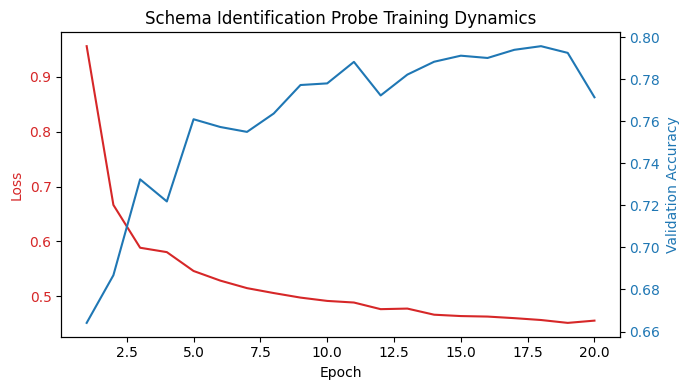

In [15]:
history = json.load(open("analysis/history.json"))

epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_acc = [h["val_acc"] for h in history]

fig, ax1 = plt.subplots(figsize=(7, 4))

# Train loss
ax1.plot(epochs, train_loss, label="Train Loss", color="tab:red")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Validation accuracy
ax2 = ax1.twinx()
ax2.plot(epochs, val_acc, label="Val Accuracy", color="tab:blue")
ax2.set_ylabel("Validation Accuracy", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Schema Identification Probe Training Dynamics")
fig.tight_layout()
plt.show()


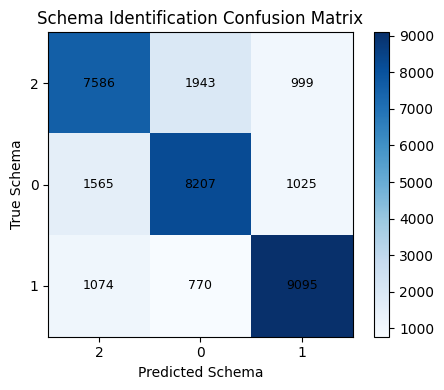

In [18]:
conf = json.load(open("analysis/confusion.json"))

# ---- Case A: dict-of-dicts ----
if isinstance(conf, dict) and "matrix" not in conf:
    labels = list(conf.keys())
    matrix = np.array([[conf[r][c] for c in labels] for r in labels])

# ---- Case B: explicit matrix only ----
else:
    matrix = np.array(conf["matrix"])
    labels = conf.get("labels", [f"schema_{i}" for i in range(matrix.shape[0])])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matrix, cmap="Blues")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.xlabel("Predicted Schema")
plt.ylabel("True Schema")
plt.title("Schema Identification Confusion Matrix")

# annotate cells
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Ablation Studies

In [9]:
"""
Run systematic ablation studies for schema identifiability (C1).

Each ablation specifies a subset of FEATURE_KEYS to keep.
Trains the same model + hyperparams for fair comparison.
Logs results to JSON for paper-ready tables.
"""

# ---------------------------------------------------------
# Ablation definitions
# ---------------------------------------------------------
ABLATIONS = {
    # ---------- Baseline ----------
    "B0_all": FEATURE_KEYS,

    # ---------- Remove groups ----------
    "A1_no_text": [
        k for k in FEATURE_KEYS
        if k not in {"entropy", "query_length", "num_tokens"}
    ],

    "A2_no_cost": [
        k for k in FEATURE_KEYS
        if k not in {"estimated_cost", "complexity_score"}
    ],

    "A3_no_depth": [
        k for k in FEATURE_KEYS
        if k not in {
            "query_depth",
            "avg_depth",
            "branching_factor",
            "node_count",
            "num_nested_selections",
        }
    ],

    "A4_no_counts": [
        k for k in FEATURE_KEYS
        if k not in {
            "num_fields",
            "num_fragments",
            "num_directives",
            "num_aliases",
            "num_operations",
            "num_mutations",
            "num_subscriptions",
            "num_variables",
            "num_arguments",
            "num_introspection_ops",
        }
    ],

    # ---------- Single-family ----------
    "B1_depth_only": [
        "query_depth",
        "avg_depth",
        "branching_factor",
        "node_count",
        "num_nested_selections",
    ],

    "B2_counts_only": [
        "num_fields",
        "num_fragments",
        "num_directives",
        "num_aliases",
        "num_operations",
        "num_mutations",
        "num_subscriptions",
        "num_variables",
        "num_arguments",
        "num_introspection_ops",
    ],

    "B3_cost_only": [
        "estimated_cost",
        "complexity_score",
    ],

    "B4_text_only": [
        "entropy",
        "query_length",
        "num_tokens",
    ],

    # ---------- Minimal ----------
    "C1_core_structural": [
        "query_depth",
        "branching_factor",
        "num_fields",
    ],
}

In [10]:
# ---------------------------------------------------------
# Utilities
# ---------------------------------------------------------
def filter_features(x, keys, key_to_idx):
    idxs = [key_to_idx[k] for k in keys]
    return x[:, idxs]

In [11]:
def train_and_eval(
    train_loader,
    val_loader,
    feature_keys,
    device,
    epochs=20,
):
    key_to_idx = {k: i for i, k in enumerate(FEATURE_KEYS)}

    model = FeatureSchemaClassifier(
        input_dim=len(feature_keys),
        num_classes=3,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_val = 0.0

    for epoch in range(1, epochs + 1):
        # ---------------- TRAIN ----------------
        model.train()
        train_pbar = tqdm(
            train_loader,
            desc=f"[Epoch {epoch:02d}] Train",
            leave=False,
        )

        for x, y in train_pbar:
            x, y = x.to(device), y.to(device)
            x = filter_features(x, feature_keys, key_to_idx)

            loss = criterion(model(x), y)
            opt.zero_grad()
            loss.backward()
            opt.step()

            train_pbar.set_postfix(loss=loss.item())

        # ---------------- VALIDATE ----------------
        model.eval()
        correct, total = 0, 0

        val_pbar = tqdm(
            val_loader,
            desc=f"[Epoch {epoch:02d}] Val",
            leave=False,
        )

        with torch.no_grad():
            for x, y in val_pbar:
                x, y = x.to(device), y.to(device)
                x = filter_features(x, feature_keys, key_to_idx)
                pred = model(x).argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        acc = correct / total
        best_val = max(best_val, acc)

        tqdm.write(f"[Epoch {epoch:02d}] val_acc={acc:.4f}")

    return best_val


In [12]:
# ---------------------------------------------------------
# Main
# ---------------------------------------------------------
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train", required=True)
    parser.add_argument("--val", required=True)
    parser.add_argument("--out", default="analysis/ablation_results.json")
    parser.add_argument("--epochs", type=int, default=20)
    args = parser.parse_args()

    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader, val_loader = build_feature_schema_dataloaders(
        train_path=args.train,
        val_path=args.val,
        batch_size=128,
    )

    results = {}

    for name, keys in tqdm(ABLATIONS.items(), desc="Ablations"):
        acc = train_and_eval(
            train_loader,
            val_loader,
            keys,
            device,
            epochs=args.epochs,
        )

        results[name] = {
            "num_features": len(keys),
            "val_accuracy": acc,
            "features": keys,
        }

        print(f"{name:18s} | acc={acc:.4f}")

    out_path = Path(args.out)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w") as f:
        json.dump(results, f, indent=2)

    print("\nAblation results written to:", out_path)

In [13]:
import sys

sys.argv = [
    "run_feature_ablation",
    "--train", "/kaggle/input/graphql-feature-schema-dataset/train.jsonl",
    "--val", "/kaggle/input/graphql-feature-schema-dataset/val.jsonl",
    "--epochs", "20",
]

main()


Ablations:   0%|          | 0/10 [00:00<?, ?it/s]

[Epoch 01] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

[Epoch 01] Val:   0%|          | 0/253 [00:00<?, ?it/s]

[Epoch 01] val_acc=0.6324


[Epoch 02] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

...

[Epoch 19] Val:   0%|          | 0/253 [00:00<?, ?it/s]

[Epoch 19] val_acc=0.5459


[Epoch 20] Train:   0%|          | 0/1009 [00:00<?, ?it/s]

[Epoch 20] Val:   0%|          | 0/253 [00:00<?, ?it/s]

[Epoch 20] val_acc=0.5412
C1_core_structural | acc=0.5459

Ablation results written to: analysis/ablation_results.json


In [16]:
with open('analysis/ablation_results.json', 'r') as file:
    for i in range(50):
        line = file.readline()
        if not line:
            break
        print(line.strip())

{
"B0_all": {
"num_features": 21,
"val_accuracy": 0.7999318125464915,
"features": [
"num_fields",
"num_fragments",
"num_directives",
"num_aliases",
"num_operations",
"num_mutations",
"num_subscriptions",
"num_variables",
"num_arguments",
"num_introspection_ops",
"query_depth",
"avg_depth",
"branching_factor",
"node_count",
"num_nested_selections",
"estimated_cost",
"complexity_score",
"entropy",
"query_length",
"num_tokens",
"has_error"
]
},
"A1_no_text": {
"num_features": 18,
"val_accuracy": 0.6237292338209769,
"features": [
"num_fields",
"num_fragments",
"num_directives",
"num_aliases",
"num_operations",
"num_mutations",
"num_subscriptions",
"num_variables",
"num_arguments",
"num_introspection_ops",
"query_depth",
"avg_depth",
"branching_factor",
"node_count",
"num_nested_selections",
"estimated_cost",
"complexity_score",
"has_error"


In [17]:
with open("analysis/ablation_results.json", "r") as f:
    raw = json.load(f)

# flatten for plotting
labels = []
accs = []
num_feats = []

for name, entry in raw.items():
    labels.append(name)
    accs.append(entry["val_accuracy"])
    num_feats.append(entry["num_features"])

In [18]:
# sort by accuracy descending
order = sorted(range(len(accs)), key=lambda i: accs[i], reverse=True)

labels = [labels[i] for i in order]
accs = [accs[i] for i in order]
num_feats = [num_feats[i] for i in order]

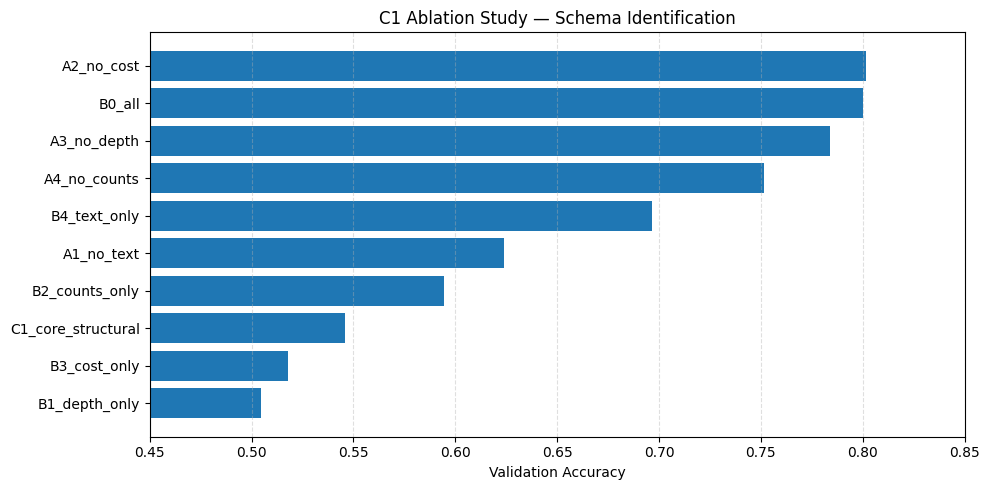

In [19]:
plt.figure(figsize=(10, 5))
plt.barh(labels, accs)
plt.xlabel("Validation Accuracy")
plt.title("C1 Ablation Study — Schema Identification")
plt.xlim(0.45, 0.85)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

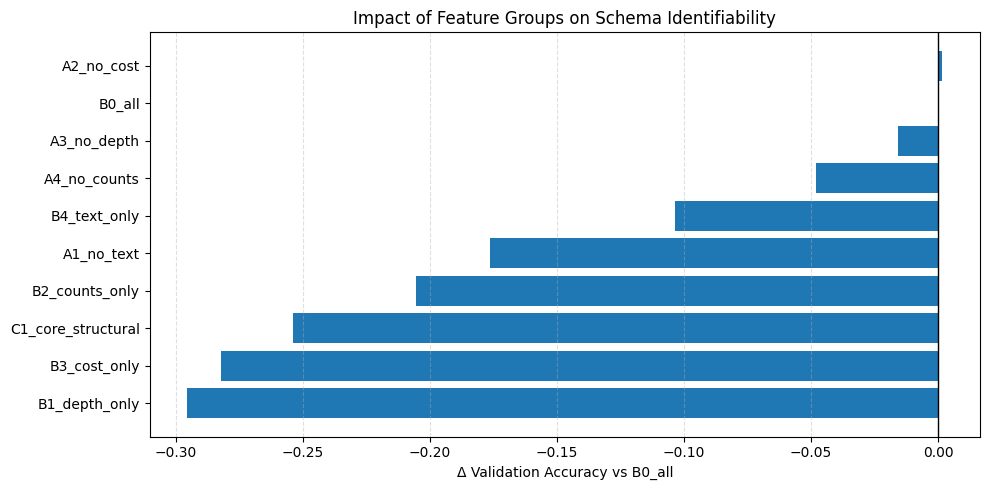

In [20]:
baseline = raw["B0_all"]["val_accuracy"]
deltas = [a - baseline for a in accs]

plt.figure(figsize=(10, 5))
plt.barh(labels, deltas)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Δ Validation Accuracy vs B0_all")
plt.title("Impact of Feature Groups on Schema Identifiability")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

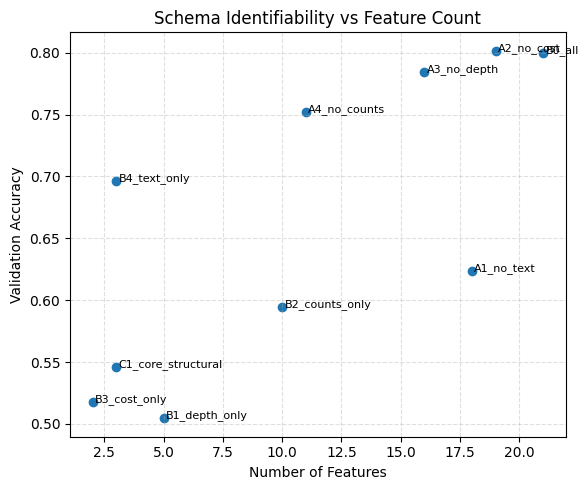

In [21]:
plt.figure(figsize=(6, 5))
plt.scatter(num_feats, accs)

for x, y, label in zip(num_feats, accs, labels):
    plt.text(x + 0.1, y, label, fontsize=8)

plt.xlabel("Number of Features")
plt.ylabel("Validation Accuracy")
plt.title("Schema Identifiability vs Feature Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Text Schema Agnosticity Checks

### Dataset

In [22]:
class SchemaTextDataset(Dataset):
    """
    JSONL format:
    {
      "text": "...GraphQL query...",
      "y": int,
      "schema": "schema_g1"
    }
    """

    def __init__(self, jsonl_path, tokenizer, max_len=256):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_len = max_len

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                self.samples.append(json.loads(line))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples[idx]
        enc = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(row["y"], dtype=torch.long),
        )

### DataLoader

In [33]:

def build_schema_text_dataloaders(
    train_path,
    val_path,
    model_name="roberta-base",
    batch_size=16,
    max_len=128,
    num_workers=0,
):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = SchemaTextDataset(train_path, tokenizer, max_len)
    val_ds   = SchemaTextDataset(val_path, tokenizer, max_len)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader, tokenizer

### Model

In [30]:
class SchemaTextClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)

        for p in self.encoder.parameters():
            p.requires_grad = False   # 🔒 freeze

        hidden = self.encoder.config.hidden_size
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # 🔒 no encoder grads
            out = self.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
        pooled = out.last_hidden_state[:, 0]
        return self.head(pooled)


### Training COnfiguration

In [34]:
def train_schema_text():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    NUM_SCHEMAS = 3
    MODEL_NAME = "roberta-base"
    EPOCHS = 3
    LR = 2e-5

    train_loader, val_loader, _ = build_schema_text_dataloaders(
        train_path="/kaggle/input/graphql-schema-agnosticity-text/train.jsonl",
        val_path="/kaggle/input/graphql-schema-agnosticity-text/val.jsonl",
        model_name=MODEL_NAME,
        batch_size=16,
    )

    model = SchemaTextClassifier(
        model_name=MODEL_NAME,
        num_classes=NUM_SCHEMAS,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    history = []

    for epoch in range(1, EPOCHS + 1):
        # ---- TRAIN ----
        model.train()
        train_loss = 0.0

        for ids, mask, y in tqdm(train_loader, desc=f"Epoch {epoch:02d} Train"):
            ids, mask, y = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)

            logits = model(ids, mask)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ---- VALIDATE ----
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for ids, mask, y in tqdm(val_loader, desc=f"Epoch {epoch:02d} Val"):
                ids, mask, y = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
                preds = model(ids, mask).argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_acc = correct / total

        history.append({
            "epoch": epoch,
            "train_loss": train_loss / len(train_loader),
            "val_acc": val_acc,
        })

        print(f"[Epoch {epoch:02d}] val_acc={val_acc:.4f}")

    # ---- SAVE ----
    out = Path("analysis")
    out.mkdir(exist_ok=True)

    with open(out / "text_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("C2′ training complete → analysis/text_history.json")

### Training

In [35]:
# train_schema_text()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01 Train:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 01 Val:   0%|          | 0/2500 [00:00<?, ?it/s]

[Epoch 01] val_acc=0.8207


Epoch 02 Train:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 02 Val:   0%|          | 0/2500 [00:00<?, ?it/s]

[Epoch 02] val_acc=0.8884


Epoch 03 Train:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 03 Val:   0%|          | 0/2500 [00:00<?, ?it/s]

[Epoch 03] val_acc=0.8949
C2′ training complete → analysis/text_history.json


## TF-IDF + Logiistic Regression

In [39]:
import json
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


# -------------------------------------------------
# Load JSONL
# -------------------------------------------------
def load_jsonl(path):
    texts, labels = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            texts.append(r["text"])
            labels.append(r["y"])
    return texts, labels


X_train, y_train = load_jsonl("/kaggle/input/graphql-schema-agnosticity-text/train.jsonl")
X_val, y_val     = load_jsonl("/kaggle/input/graphql-schema-agnosticity-text/val.jsonl")

print(f"Train samples: {len(X_train)}")
print(f"Val samples:   {len(X_val)}")


# -------------------------------------------------
# TF-IDF Vectorization (with progress)
# -------------------------------------------------
print("\nVectorizing text (char n-grams)...")

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=5,
    max_features=200_000,
)

X_train_vec = vectorizer.fit_transform(
    tqdm(X_train, desc="TF-IDF fit")
)
X_val_vec = vectorizer.transform(
    tqdm(X_val, desc="TF-IDF transform")
)


# -------------------------------------------------
# Logistic Regression (epoch-style training)
# -------------------------------------------------
clf = LogisticRegression(
    max_iter=1,
    warm_start=True,
    n_jobs=-1,
    multi_class="auto",
)

EPOCHS = 10
best_acc = 0.0

print("\nTraining Logistic Regression:")

for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    clf.fit(X_train_vec, y_train)

    preds = clf.predict(X_val_vec)
    acc = accuracy_score(y_val, preds)
    best_acc = max(best_acc, acc)

    tqdm.write(f"[Epoch {epoch:02d}] val_acc={acc:.4f}")


# -------------------------------------------------
# Final evaluation
# -------------------------------------------------
print("\n=== C2′-a RESULTS ===")
print(f"Best validation accuracy: {best_acc:.4f}\n")
print(classification_report(y_val, preds, digits=4))


Train samples: 160000
Val samples:   40000

Vectorizing text (char n-grams)...


TF-IDF fit:   0%|          | 0/160000 [00:00<?, ?it/s]

TF-IDF transform:   0%|          | 0/40000 [00:00<?, ?it/s]


Training Logistic Regression:


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

...

[Epoch 08] val_acc=0.9522


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[Epoch 09] val_acc=0.9571


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[Epoch 10] val_acc=0.9633

=== C2′-a RESULTS ===
Best validation accuracy: 0.9811

              precision    recall  f1-score   support

           0     0.9804    0.9279    0.9534     13407
           1     0.9200    1.0000    0.9583     13400
           2     0.9959    0.9620    0.9787     13193

    accuracy                         0.9633     40000
   macro avg     0.9654    0.9633    0.9635     40000
weighted avg     0.9653    0.9633    0.9634     40000

